In [2]:
print("M Raihan Nawaz2124")

M Raihan Nawaz2124


In [3]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
customer_df = pd.read_csv(r'C:\Users\M Reehan nawaz\OneDrive\Desktop\Datasets\online+shoppers+purchasing+intention+dataset\customers_dataset.csv')

rows, columns = customer_df.shape
print("\nRows: ", rows)
print("\nColumns: ", columns)
target_var = customer_df.columns[-1]
print("\nTarget_column: ",target_var)
print(f"Customer_data columns: {customer_df.columns.tolist()}")




Rows:  12330

Columns:  18

Target_column:  Revenue
Customer_data columns: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']


In [4]:
customer_df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [5]:
print("unneccessary values in each column")
print('\n')
columns_list = customer_df.columns

for col in columns_list:
    count = ((customer_df[col] == 0) | (customer_df[col] == 0.0) | (customer_df[col].isnull())).sum()
    print(col, count)

unneccessary values in each column


Administrative 5768
Administrative_Duration 5903
Informational 9699
Informational_Duration 9925
ProductRelated 38
ProductRelated_Duration 755
BounceRates 5518
ExitRates 76
PageValues 9600
SpecialDay 11079
Month 0
OperatingSystems 0
Browser 0
Region 0
TrafficType 0
VisitorType 0
Weekend 9462
Revenue 10422


In [6]:
print("Duplicate rows")
print(customer_df.duplicated().sum())


print("\nTotal_unique values in dataset: ", customer_df.nunique().sum())

print('unnecessary_value', abs(len(customer_df) - customer_df.nunique().sum()))
print("Total_values: ", len(customer_df))

Duplicate rows
125

Total_unique values in dataset:  23925
unnecessary_value 11595
Total_values:  12330


In [7]:
# Categorical columns

print("Categorical_columns")
categorical_cols = customer_df.select_dtypes(include='object')
categorical_cols

Categorical_columns


C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_15268\1500880972.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = customer_df.select_dtypes(include='object')


,Month,VisitorType
0,Feb,Returning_Visitor
1,Feb,Returning_Visitor
2,Feb,Returning_Visitor
3,Feb,Returning_Visitor
4,Feb,Returning_Visitor
...,...,...
12325,Dec,Returning_Visitor
12326,Nov,Returning_Visitor
12327,Nov,Returning_Visitor
12328,Nov,Returning_Visitor


In [8]:
# Numerical Columns
numerical_columns= customer_df.select_dtypes(include=np.number).columns
numerical_columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='str')

In [9]:
# Statistical analysis of dataset 

stat_analy = customer_df.describe()
stat_analy

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [10]:
print(customer_df.shape)
print(customer_df.dtypes)
print(customer_df.info())
print(customer_df.isnull().sum())
print(customer_df.duplicated().sum())
print(customer_df.nunique())
print(customer_df['Revenue'].value_counts())

(12330, 18)
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            

In [11]:
# B. Statistical Analysis

print('_' * 24)
print(' ' * 10, 'Mean')
print('_' * 24)
print(customer_df[numerical_columns].mean())
print('\n', '_' * 25)
print(' ' * 10 ,"Median")
print("_" * 25)
print(customer_df[numerical_columns].median())

print("_" * 25)
print(' ' * 10 ,"Mode")
print("_" * 25)
print(customer_df[numerical_columns].mode().iloc[0])

# Minimum 
print('_' * 25)
print('' * 10,"Minimum")
print("_" * 25)
print(customer_df[numerical_columns].min())

# Maximum 
print('_' * 24)
print('' * 10,"Maximum")
print('_' * 24)
print(round(customer_df[numerical_columns].max(), 2))

print('_' * 24)
print('' * 10,"Variance")
print('_' * 24)
print(round(customer_df[numerical_columns].var(), 2))
print('_' * 24)
print('' * 10,"Standard_deviation")
print('_' * 24)
print(customer_df[numerical_columns].std())

# Quartiles and IQR
print('_' * 28)
print('Quartiles and IQR')
print('_'* 28)

Q1 = customer_df[numerical_columns].quantile(0.25)
Q2 = customer_df[numerical_columns].quantile(0.50)
Q3 = customer_df[numerical_columns].quantile(0.75)

IQR = Q3 - Q1

IQR = Q3 - Q1

print("Q1:")
print(Q1)

print("\nQ2")
print(Q2)

print("\nQ3:")
print(Q3)

print("\nIQR:")
print(IQR)


________________________
           Mean
________________________
Administrative                2.315166
Administrative_Duration      80.818611
Informational                 0.503569
Informational_Duration       34.472398
ProductRelated               31.731468
ProductRelated_Duration    1194.746220
BounceRates                   0.022191
ExitRates                     0.043073
PageValues                    5.889258
SpecialDay                    0.061427
OperatingSystems              2.124006
Browser                       2.357097
Region                        3.147364
TrafficType                   4.069586
dtype: float64

 _________________________
           Median
_________________________
Administrative               1.000000
Administrative_Duration      7.500000
Informational                0.000000
Informational_Duration       0.000000
ProductRelated              18.000000
ProductRelated_Duration    598.936905
BounceRates                  0.003112
ExitRates                    0.0251

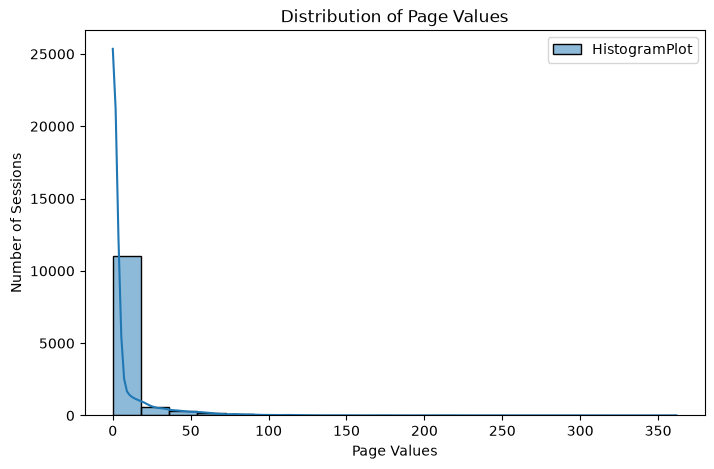

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=customer_df,
    x='PageValues',
    bins=20,
    kde=True,
    label='HistogramPlot'
)

plt.title('Distribution of Page Values')
plt.xlabel('Page Values')
plt.ylabel('Number of Sessions')

plt.legend()
plt.show()


                         Administrative  Administrative_Duration  \
Administrative                 1.000000                 0.601583   
Administrative_Duration        0.601583                 1.000000   
Informational                  0.376850                 0.302710   
Informational_Duration         0.255848                 0.238031   
ProductRelated                 0.431119                 0.289087   
ProductRelated_Duration        0.373939                 0.355422   
BounceRates                   -0.223563                -0.144170   
ExitRates                     -0.316483                -0.205798   
PageValues                     0.098990                 0.067608   
SpecialDay                    -0.094778                -0.073304   
OperatingSystems              -0.006347                -0.007343   
Browser                       -0.025035                -0.015392   
Region                        -0.005487                -0.005561   
TrafficType                   -0.033561         

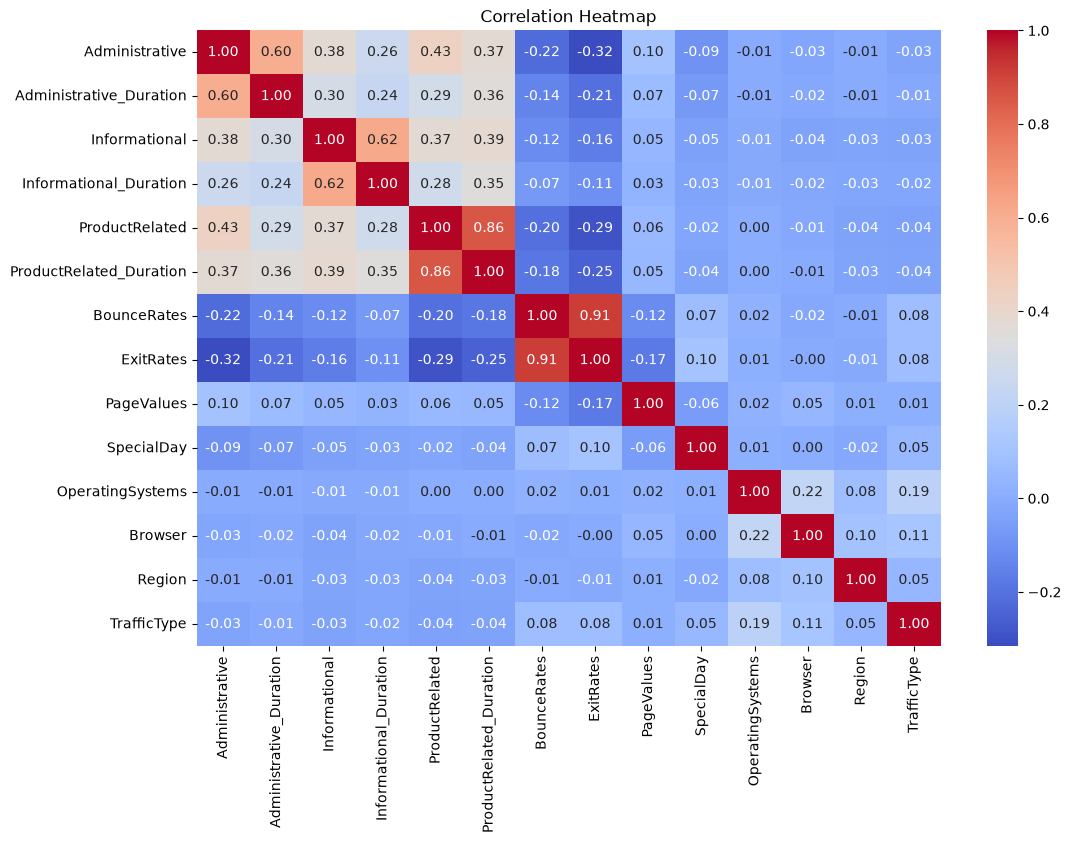

In [15]:
correlation = customer_df[numerical_columns].corr()
print(correlation)
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

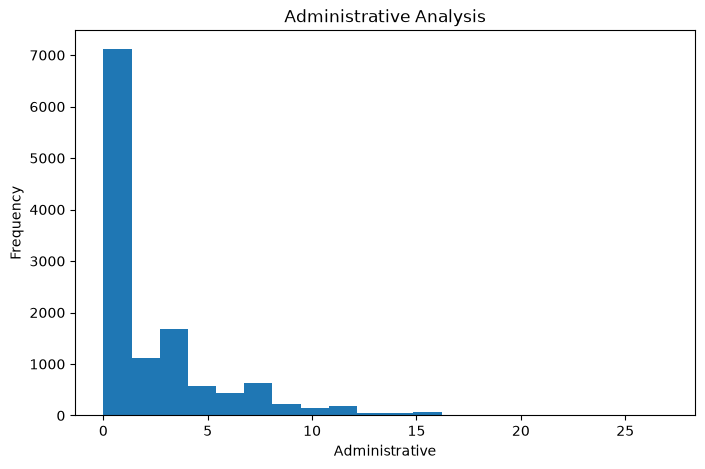

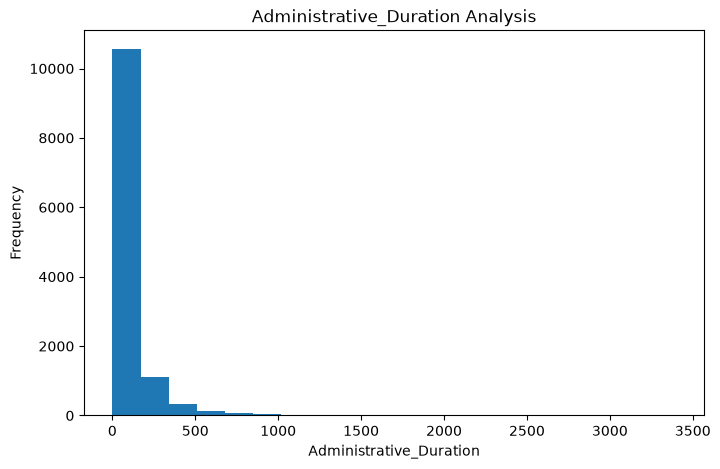

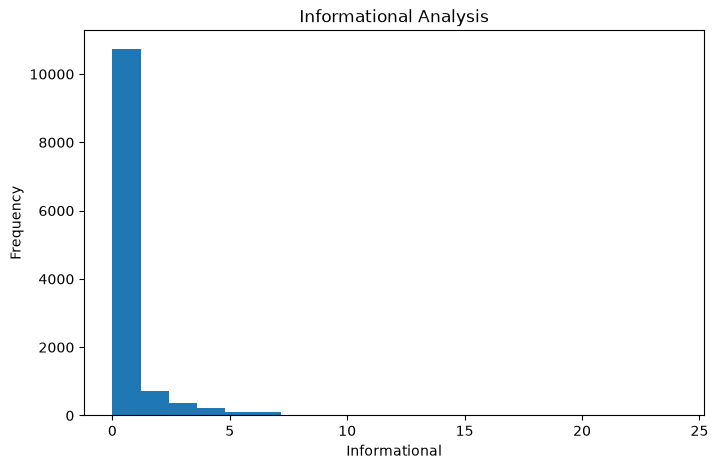

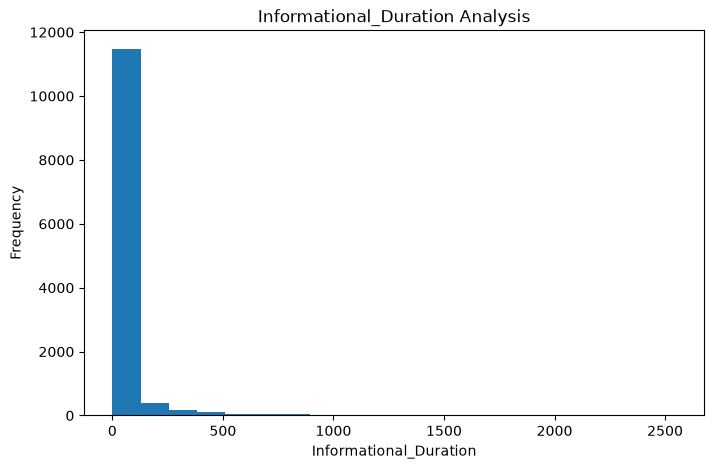

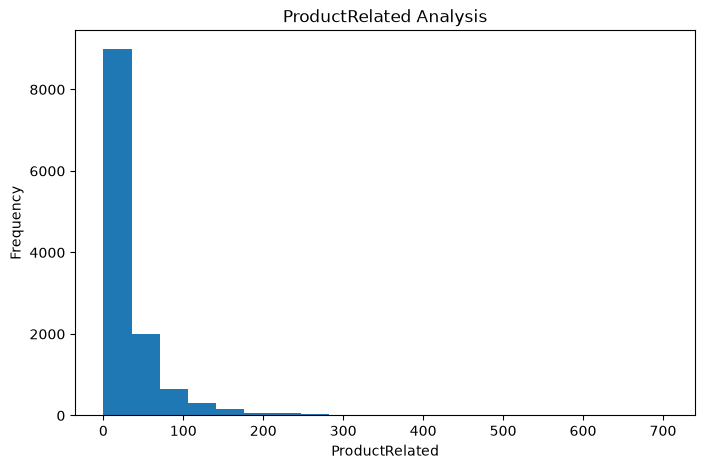

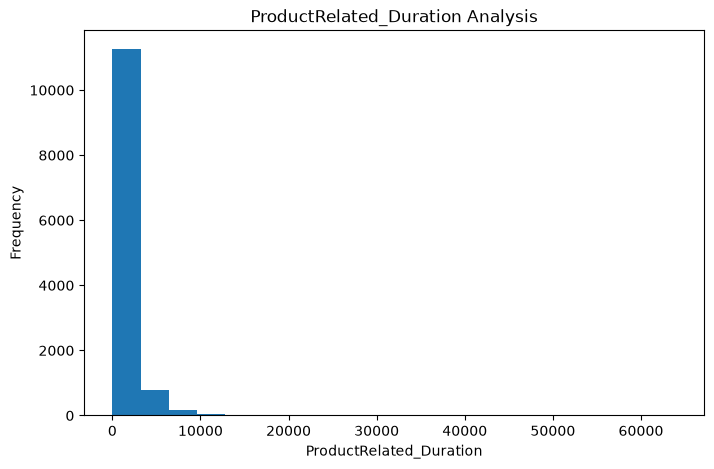

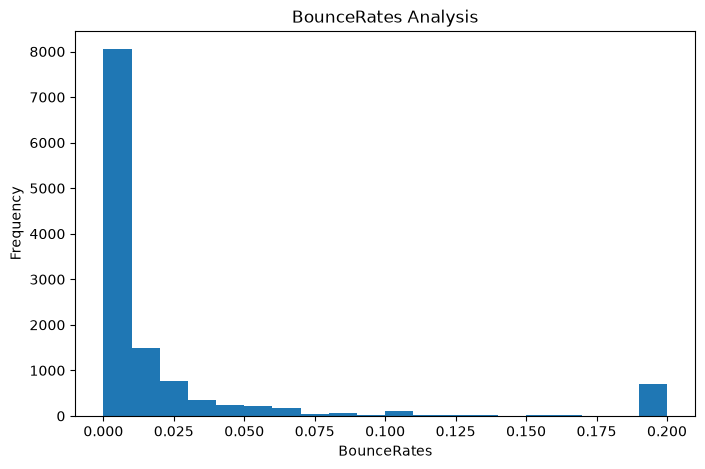

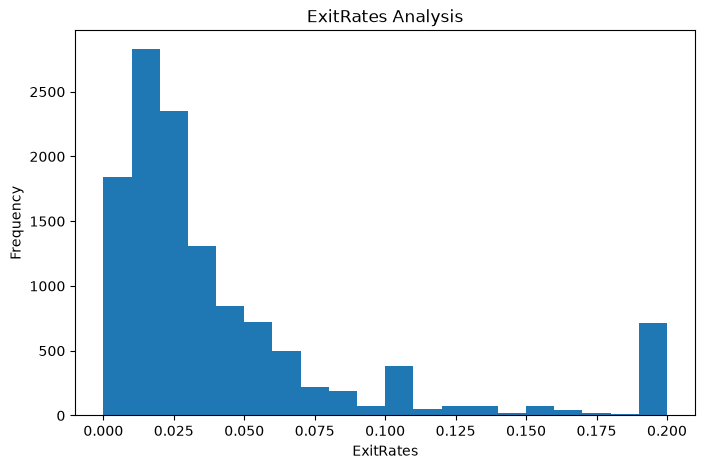

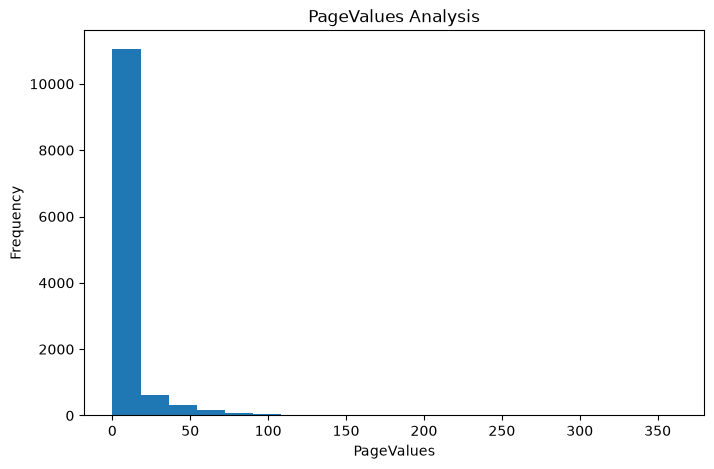

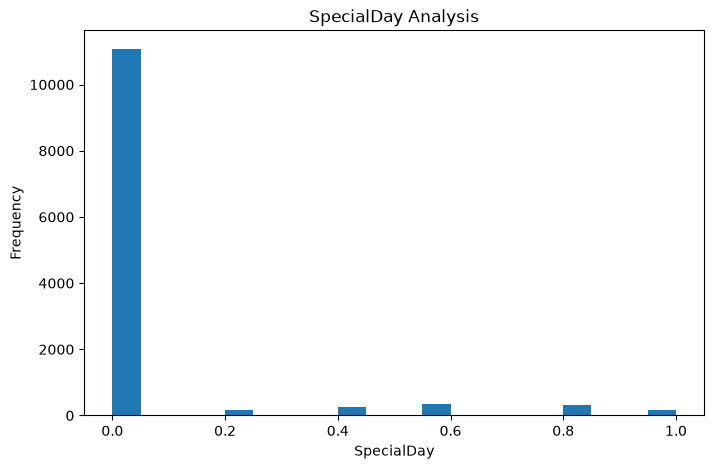

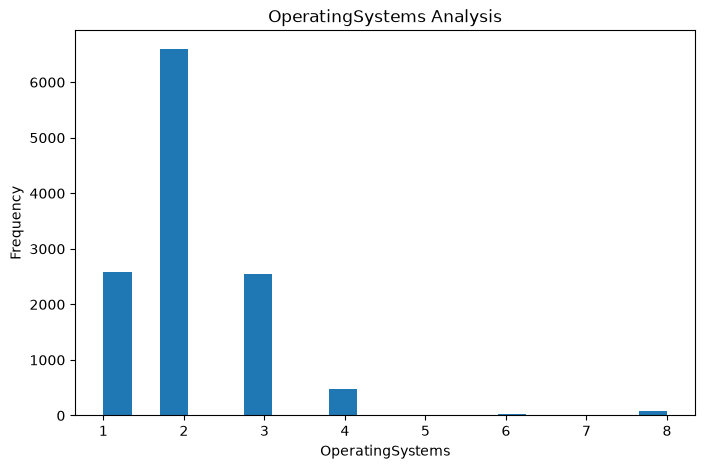

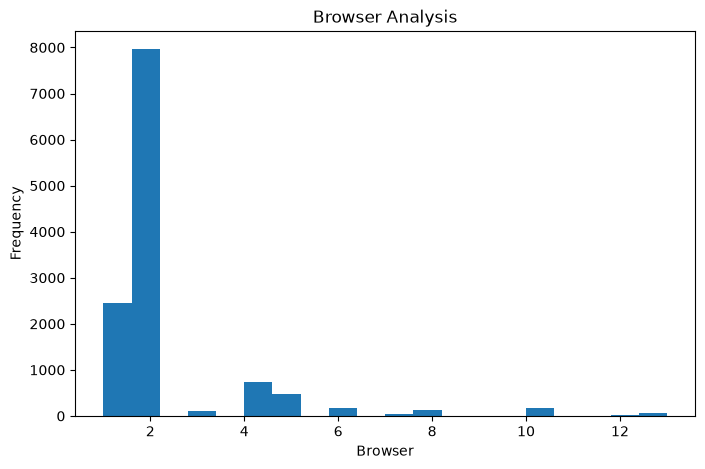

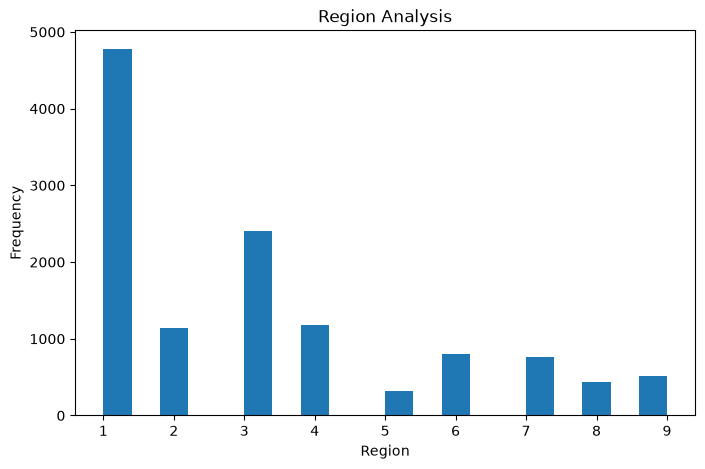

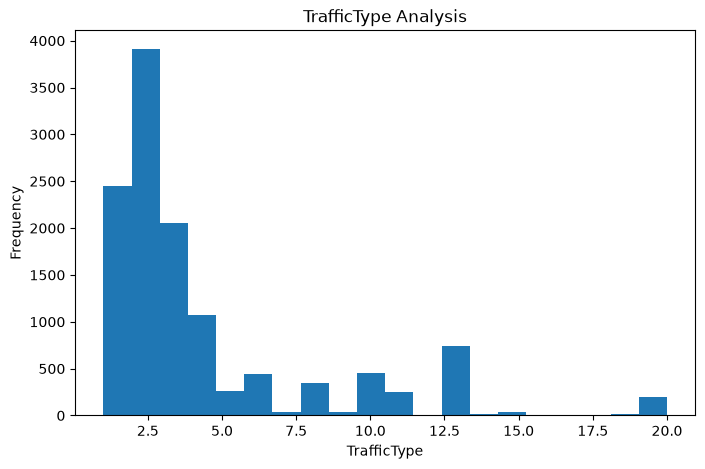

In [16]:
# 7. Exploratory Data Analysis (EDA)
# Univariate Analysis is used for analyzing one column at a time.

for each_col in numerical_columns:

    plt.figure(figsize=(8,5))

    plt.hist(customer_df[each_col], bins=20)

    plt.title(f"{each_col} Analysis")
    plt.xlabel(each_col)
    plt.ylabel("Frequency")

    plt.show()

In [17]:
# Bivariate — two columns at a time

# for i in range(len(numerical_columns)):

#     for j in range(i + 1, len(numerical_columns)):

#         col1 = numerical_columns[i]
#         col2 = numerical_columns[j]

#         plt.figure(figsize=(8,5))

#         plt.scatter(
#             customer_df[col1],
#             customer_df[col2]
#         )

#         plt.title(f"{col1} vs {col2}")
#         plt.xlabel(col1)
#         plt.ylabel(col2)

#         plt.show()

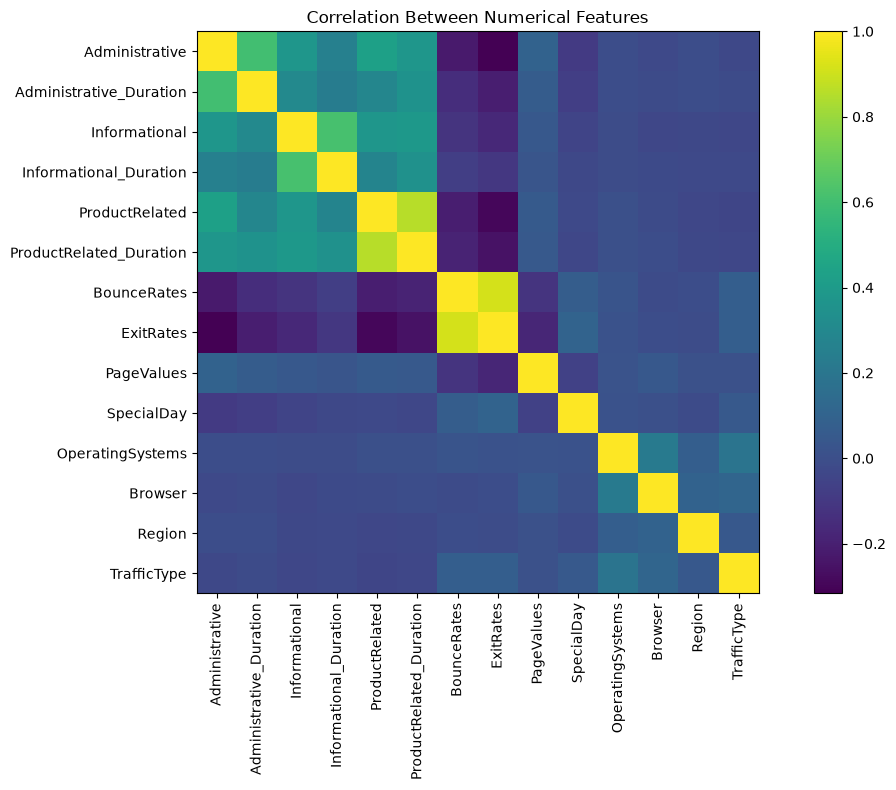

In [18]:
# Multivariate means 3 columns at a time 

correlation = customer_df[numerical_columns].corr()

plt.figure(figsize=(12,8))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(
    range(len(numerical_columns)),
    numerical_columns,
    rotation=90
)

plt.yticks(
    range(len(numerical_columns)),
    numerical_columns
)

plt.title("Correlation Between Numerical Features")

plt.tight_layout()

plt.show()

In [19]:
# 8 Customer segmentation start with features that describe shopping behavior

segmentation_feat = numerical_columns[:9]
segmentation_feat

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues'],
      dtype='str')

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
dtype: int64


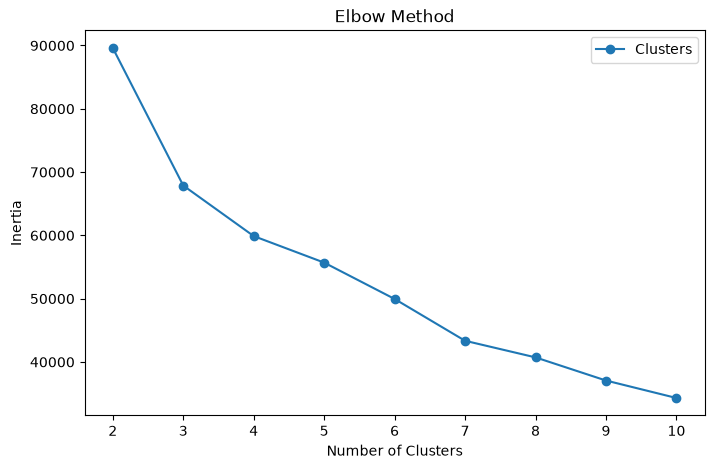

Cluster
0    8259
1     601
2     924
3    2546
Name: count, dtype: int64


In [20]:
X = customer_df[segmentation_feat].copy()

print(X.isnull().sum())

# 4. Scale the data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# K-Means Clustering

from sklearn.cluster import KMeans 

inertia =[]

for k in range(2, 11):
    model = KMeans(
        n_clusters=k, random_state=42
    )
    model.fit(X_scaled)

    inertia.append(model.inertia_)


# Elbow Method

plt.figure(figsize=(8,5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o", 
    label='Clusters'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.legend()
plt.show()

# final K-Means model

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_df["Cluster"] = kmeans.fit_predict(X_scaled)
print(customer_df["Cluster"].value_counts().sort_index())

In [21]:
# 15 Analyze the characteristics of each cluster

cluster_profile = customer_df.groupby("Cluster")[
    segmentation_feat
].mean()

print(cluster_profile)

# including Revenue AFTER clustering
revenue_by_cluster = customer_df.groupby("Cluster")["Revenue"].mean() * 100

print(revenue_by_cluster)

         Administrative  Administrative_Duration  Informational  \
Cluster                                                           
0              0.997094                26.857963       0.182468   
1              7.046589               262.744837       4.000000   
2              0.032468                 1.140188       0.009740   
3              6.302435               241.834396       0.899057   

         Informational_Duration  ProductRelated  ProductRelated_Duration  \
Cluster                                                                    
0                      7.286422       20.925415               766.095791   
1                    440.174124      136.991681              5690.184737   
2                      0.000000        2.617965                45.304091   
3                     39.403557       52.503928              1941.230853   

         BounceRates  ExitRates  PageValues  
Cluster                                      
0           0.010742   0.036110    3.335284  
1 

In [22]:
# Hierarchical Clustering

from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=4
)

customer_df["Hierarchical_Cluster"] = hierarchical.fit_predict(X_scaled)
print(
    customer_df["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
)

Hierarchical_Cluster
0    1897
1    8427
2    1279
3     727
Name: count, dtype: int64


In [23]:
# Compare K-Means and Hierarchical
print("K-Means:")
print(customer_df["Cluster"].value_counts().sort_index())

print("\nHierarchical:")
print(
    customer_df["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
)

K-Means:
Cluster
0    8259
1     601
2     924
3    2546
Name: count, dtype: int64

Hierarchical:
Hierarchical_Cluster
0    1897
1    8427
2    1279
3     727
Name: count, dtype: int64


In [24]:

# 9 PURCHASE PREDICTION


import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier


# ------------------------------------------------------------
# 1. Separate features and target
# ------------------------------------------------------------

X = customer_df.drop("Revenue", axis=1)
y = customer_df["Revenue"]


# ------------------------------------------------------------
# 2. Identify numerical and categorical columns
# ------------------------------------------------------------

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = X.select_dtypes(
    include=["object", "bool"]
).columns


# ------------------------------------------------------------
# 3. Handle missing values
# ------------------------------------------------------------

X[numerical_columns] = X[numerical_columns].fillna(
    X[numerical_columns].median()
)

X[categorical_columns] = X[categorical_columns].fillna(
    X[categorical_columns].mode().iloc[0]
)


# ------------------------------------------------------------
# 4. Encode categorical columns
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_columns
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ]
)


# ------------------------------------------------------------
# 5. Train-Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ------------------------------------------------------------
# 6. Transform the data
# ------------------------------------------------------------

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


# ------------------------------------------------------------
# 7. Create classification models
# ------------------------------------------------------------

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "AdaBoost":
        AdaBoostClassifier(
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        )
}

# Training all models

trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    trained_models[name] = model

    print(f"{name} trained successfully")

print("\nAll models trained.")

Logistic Regression trained successfully


C:\Users\M Reehan nawaz\AppData\Local\Temp\ipykernel_15268\131769473.py:34: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


Decision Tree trained successfully
Random Forest trained successfully
AdaBoost trained successfully
KNN trained successfully

All models trained.


In [25]:

# 10. MODEL EVALUATION


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

results = []

for name, model in trained_models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probability for ROC-AUC
    y_probability = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_probability
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print("=" * 50)
    print(name)

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))

    print("\nConfusion Matrix:")
    print(cm)


# Convert results into DataFrame

results_df = pd.DataFrame(results)

print("\n\nMODEL COMPARISON")
print(results_df)

Logistic Regression
Accuracy : 0.8824
Precision: 0.7473
Recall   : 0.3639
F1 Score : 0.4894
ROC-AUC  : 0.8875

Confusion Matrix:
[[2037   47]
 [ 243  139]]
Decision Tree
Accuracy : 0.871
Precision: 0.5874
Recall   : 0.5628
F1 Score : 0.5749
ROC-AUC  : 0.7452

Confusion Matrix:
[[1933  151]
 [ 167  215]]
Random Forest
Accuracy : 0.9027
Precision: 0.7536
Recall   : 0.5524
F1 Score : 0.6375
ROC-AUC  : 0.9197

Confusion Matrix:
[[2015   69]
 [ 171  211]]
AdaBoost
Accuracy : 0.8966
Precision: 0.7003
Recall   : 0.5812
F1 Score : 0.6352
ROC-AUC  : 0.9123

Confusion Matrix:
[[1989   95]
 [ 160  222]]
KNN
Accuracy : 0.8706
Precision: 0.6413
Recall   : 0.3743
F1 Score : 0.4727
ROC-AUC  : 0.7781

Confusion Matrix:
[[2004   80]
 [ 239  143]]


MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.882401   0.747312  0.363874  0.489437  0.887457
1        Decision Tree  0.871046   0.587432  0.562827  0.574866  0.745185
2        Random For

In [26]:
# Accuracy
# → How many predictions are correct overall?

# Precision
# → When model says "Purchase", how often is it correct?

# Recall
# → Of the actual purchasers, how many did the model find?

# F1
# → Balance between Precision and Recall.

# ROC-AUC
# → How well can the model distinguish Purchase vs No Purchase?

In [27]:

# 11. VALIDATING THE RESULTS

from sklearn.metrics import accuracy_score

validation_results = []

for name, model in trained_models.items():

    # Training prediction
    train_pred = model.predict(X_train)

    # Testing prediction
    test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )

    test_accuracy = accuracy_score(
        y_test,
        test_pred
    )

    difference = train_accuracy - test_accuracy

    validation_results.append({
        "Model": name,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Difference": difference
    })


validation_df = pd.DataFrame(
    validation_results
)

print("TRAINING VS TESTING")
print(validation_df)



# Confusion Matrix for each model


for name, model in trained_models.items():

    predictions = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        predictions
    )

    print("\n" + "=" * 50)
    print(name)

    print("Confusion Matrix:")
    print(cm)



# Incorrect predictions
for name, model in trained_models.items():

    predictions = model.predict(X_test)

    incorrect = (predictions != y_test).sum()

    print(
        f"{name} incorrect predictions: {incorrect}"
    )

TRAINING VS TESTING
                 Model  Training Accuracy  Testing Accuracy  Difference
0  Logistic Regression           0.886050          0.882401    0.003650
1        Decision Tree           1.000000          0.871046    0.128954
2        Random Forest           1.000000          0.902676    0.097324
3             AdaBoost           0.891930          0.896594   -0.004663
4                  KNN           0.906427          0.870641    0.035787

Logistic Regression
Confusion Matrix:
[[2037   47]
 [ 243  139]]

Decision Tree
Confusion Matrix:
[[1933  151]
 [ 167  215]]

Random Forest
Confusion Matrix:
[[2015   69]
 [ 171  211]]

AdaBoost
Confusion Matrix:
[[1989   95]
 [ 160  222]]

KNN
Confusion Matrix:
[[2004   80]
 [ 239  143]]
Logistic Regression incorrect predictions: 290
Decision Tree incorrect predictions: 318
Random Forest incorrect predictions: 240
AdaBoost incorrect predictions: 255
KNN incorrect predictions: 319


In [28]:

# 12. BUSINESS INSIGHTS & RECOMMENDATIONS

# 1. Purchase rate


purchase_rate = customer_df["Revenue"].mean() * 100

print(
    f"Overall purchase rate: {purchase_rate:.2f}%"
)


# ------------------------------------------------------------
# 2. Purchase rate by Visitor Type
# ------------------------------------------------------------

visitor_purchase = (
    customer_df
    .groupby("VisitorType")["Revenue"]
    .mean()
    * 100
)

print("\nPurchase Rate by Visitor Type:")
print(visitor_purchase)


# ------------------------------------------------------------
# 3. Purchase rate by Month
# ------------------------------------------------------------

month_purchase = (
    customer_df
    .groupby("Month")["Revenue"]
    .mean()
    * 100
)

print("\nPurchase Rate by Month:")
print(month_purchase)


# ------------------------------------------------------------
# 4. Average Page Value by Revenue
# ------------------------------------------------------------

page_value_analysis = (
    customer_df
    .groupby("Revenue")["PageValues"]
    .mean()
)

print("\nAverage Page Value:")
print(page_value_analysis)


# ------------------------------------------------------------
# 5. Average Product Related Duration
# ------------------------------------------------------------

duration_analysis = (
    customer_df
    .groupby("Revenue")[
        "ProductRelated_Duration"
    ]
    .mean()
)

print("\nAverage Product Related Duration:")
print(duration_analysis)


#  Cluster purchase rate

if "Cluster" in customer_df.columns:

    cluster_purchase = (
        customer_df
        .groupby("Cluster")["Revenue"]
        .mean()
        * 100
    )

    print("\nPurchase Rate by Customer Segment:")
    print(cluster_purchase)

Overall purchase rate: 15.47%

Purchase Rate by Visitor Type:
VisitorType
New_Visitor          24.911452
Other                18.823529
Returning_Visitor    13.932329
Name: Revenue, dtype: float64

Purchase Rate by Month:
Month
Aug     17.551963
Dec     12.507238
Feb      1.630435
Jul     15.277778
June    10.069444
Mar     10.068170
May     10.850178
Nov     25.350233
Oct     20.947177
Sep     19.196429
Name: Revenue, dtype: float64

Average Page Value:
Revenue
False     1.975998
True     27.264518
Name: PageValues, dtype: float64

Average Product Related Duration:
Revenue
False    1069.987809
True     1876.209615
Name: ProductRelated_Duration, dtype: float64

Purchase Rate by Customer Segment:
Cluster
0    11.841627
1    29.950083
2     0.541126
3    29.261587
Name: Revenue, dtype: float64


In [29]:
# Final result

print("_" * 60)
print("PROJECT FINAL OUTCOME")
print("_" * 60)

print("\n1. Customer/session segments identified using clustering.")

print("2. Multiple classification models trained for purchase prediction.")

print("3. Models evaluated using:")
print("   - Accuracy")
print("   - Precision")
print("   - Recall")
print("   - F1 Score")
print("   - ROC-AUC")
print("   - Confusion Matrix")

print("4. Training and testing performance compared.")

print("5. Important purchasing behavior analyzed.")

print("6. Business insights generated from EDA,")
print("   clustering and classification results.")

____________________________________________________________
PROJECT FINAL OUTCOME
____________________________________________________________

1. Customer/session segments identified using clustering.
2. Multiple classification models trained for purchase prediction.
3. Models evaluated using:
   - Accuracy
   - Precision
   - Recall
   - F1 Score
   - ROC-AUC
   - Confusion Matrix
4. Training and testing performance compared.
5. Important purchasing behavior analyzed.
6. Business insights generated from EDA,
   clustering and classification results.


In [30]:
print("""
PROJECT WORKFLOW

Data
  ↓
Statistical Analysis
  ↓
EDA
  ↓
Data Preprocessing
  ↓
Customer Segmentation
  ↓
K-Means Clustering
  ↓
Hierarchical Clustering
  ↓
Purchase Prediction
  ↓
Classification Models
  ↓
Model Evaluation
  ↓
Model Validation
  ↓
Business Insights
""")


PROJECT WORKFLOW

Data
  ↓
Statistical Analysis
  ↓
EDA
  ↓
Data Preprocessing
  ↓
Customer Segmentation
  ↓
K-Means Clustering
  ↓
Hierarchical Clustering
  ↓
Purchase Prediction
  ↓
Classification Models
  ↓
Model Evaluation
  ↓
Model Validation
  ↓
Business Insights

